# Exercise: Using path integration for controlling navigation

Now that we've learned how the fly can estimate its position over time, we can see how the fly can use this to help it navigate.

This is called closed loop control, where the fly's actions (how to move) depend on its sensory inputs (vision, proprioception), which are affected by its choice of action.

But first we will see why this is needed at all!

## Exercise 1: Open loop control

In this exercise, we will control the fly to walk around in a square. This requires the fly to alternate walking straight and turning on the spot.

We first start with an open loop controller, which simply executes a fixed sequence of actions without any feedback from the fly's state.

**Question:**

What might be a problem with using open loop control?

**Answer:**

Doing continuous actions like movement involves some noise, which is integrated over time to cause increasingly big errors in the fly's position, relative to where it wants to be. In open loop control, these errors are invisible to the fly and can't be corrected.

### Setting up the simulation

First we setup the arena, and create a few helper functions for plotting the fly's trajectory over time

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import trange
from flygym.compose.fly import ActuatorType
from flygym.examples.locomotion import TurningController
from flygym.simulation import Simulation
from flygym.utils.math import Rotation3D
from utils import (
    BaseBallArena,
    History,
    create_fly,
    get_variables,
    path_integrate,
    show_video,
    wrap_to_pi,
)

square_size = 10
cam_params = {
    "mode": "fixed",
    "pos_offset": (-15, 0, 6),
    "rotation": Rotation3D("euler", (1.3, 0, -np.pi / 2)),
    "fovy": 40,
}


def heading_deg_to_quat(heading_deg: float) -> Rotation3D:
    """Convert heading in degrees to a quaternion around the z axis."""
    half_angle = np.deg2rad(heading_deg) / 2
    return Rotation3D("quat", (np.cos(half_angle), 0, 0, np.sin(half_angle)))


def plot_square_trajectory(pos: np.ndarray):
    """Plot target square path against the trajectory traced by the fly."""
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.plot(
        np.array([0, 1, 1, 0, 0]) * square_size,
        np.array([0, 0, -1, -1, 0]) * square_size,
        "k--",
        label="Target trajectory",
    )
    ax.plot(*pos.T, label="Actual trajectory", c="r")
    ax.axis("equal")
    ax.set_xlabel("x position (mm)")
    ax.set_ylabel("y position (mm)")
    ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
    return fig, ax


def run_simulation(dn_drives: np.ndarray, spawn_heading_deg: float = -90):
    """Run one locomotion trial and log states."""
    fly = create_fly()
    tracking_cam = fly.add_tracking_camera(**cam_params)
    world = BaseBallArena()
    world.add_fly(
        fly,
        spawn_position=(0, 0, 0.2),
        spawn_rotation=heading_deg_to_quat(spawn_heading_deg),
    )
    world.add_light()
    sim = Simulation(world)
    sim.set_renderer(
        camera=tracking_cam,
        playback_speed=0.2,
        output_fps=25,
    )
    n_steps = len(dn_drives)
    controller = TurningController(sim.timestep)
    hist = History(n_steps, sim, fly.name)

    for i in trange(n_steps):
        joint_angles, adhesion = controller.step(dn_drives[i])
        sim.set_actuator_inputs(fly.name, ActuatorType.POSITION, joint_angles)
        sim.set_actuator_inputs(fly.name, ActuatorType.ADHESION, adhesion)
        sim.step()
        sim.render_as_needed()
        hist.step(i)

    return sim, hist.to_dict()

### Running the simulation

Now we want to create the signals to control the fly to walk in a square.

1. We first wait a small amount of time for the fly to reach a stable pose after spawning
2. Then the fly should walk straight
3. Then turn 90 degrees
4. And repeat this 3 more times until it has walked in a square pattern

In [2]:
def build_square_open_loop_drives(
    fwd_steps: int,
    turn_steps: int,
    n_turns: int = 3,
) -> np.ndarray:
    """Build open-loop descending drives for one square-like trajectory."""
    rest_drives = np.zeros((3200, 2))
    fwd_drives = np.tile([1.0, 1.0], (fwd_steps, 1))
    turn_drives = np.tile([-0.2, 1.0], (turn_steps, 1))
    return np.concatenate(
        [rest_drives] + [fwd_drives, turn_drives] * n_turns + [fwd_drives], axis=0
    )


################################################################
# TODO: Choose the right duration for the fly to walk straight and turn
# so it roughly walks in a square
forward_steps = 10000
turn_steps = 7000
################################################################

dn_drives = build_square_open_loop_drives(forward_steps, turn_steps)
sim, data = run_simulation(dn_drives)
show_video(sim)
del sim

100%|██████████| 64200/64200 [00:14<00:00, 4513.10it/s]


nmf/trackcam This browser does not support the video tag.


### Visualising the fly's trajectory

Can you change the open loop control signals to make this more accurate?

(<Figure size 300x300 with 1 Axes>,
 <Axes: xlabel='x position (mm)', ylabel='y position (mm)'>)

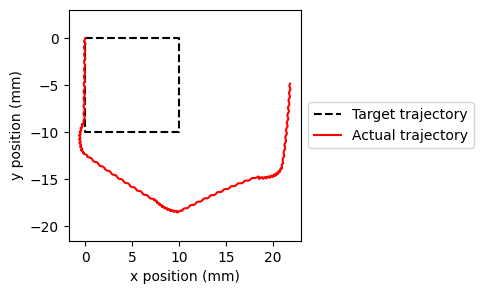

In [3]:
plot_square_trajectory(data["pos"])

## Exercise 2: Estimating the fly's position over time with proprioceptive signals

In this exercise, you will implement the model from the previous notebook to estimate changed in the fly's position and heading, based on its the stride lengths of its left and right legs.

These movements can then be integrated to track the fly's position.

In [4]:
################################################################
# TODO: Implement a model from the previous notebook that estimates
# changes in heading and forward displacement from the difference and sum
# of the stride lengths of the left and right legs
#
# These functions should take an array of length N and return and array of the same length


def heading_model(stride_win_diff_lr_diff: np.ndarray) -> np.ndarray:
    coef_ = np.array([0.22439648, 0.26674613, 0.02882383])
    intercept_ = -0.0037907851447428476
    return stride_win_diff_lr_diff @ coef_ + intercept_


def fwd_disp_model(stride_win_diff_lr_sum: np.ndarray) -> np.ndarray:
    coef_ = np.array([-0.25451459, -0.48416917, -0.0847495])
    intercept_ = -0.031104180119177816
    return stride_win_diff_lr_sum @ coef_ + intercept_

### Perform path integration

In [5]:
time_step = 1e-4
time_scale = 0.32
win_len = int(time_scale / time_step)
adhesion_force_thr = 25

path_integration_results = path_integrate(
    data,
    heading_model,
    fwd_disp_model,
    win_len,
    adhesion_force_thr,
)

### Plot the results

Text(0.5, 0, 'Time (s)')

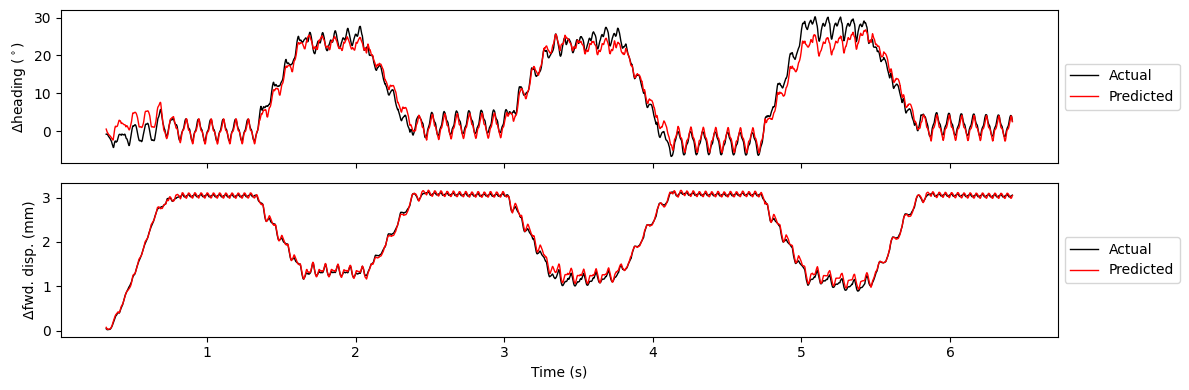

In [6]:
fig, axs = plt.subplots(2, 1, figsize=(12, 4), tight_layout=True, sharex=True)
t = np.arange(path_integration_results["heading_win_diff_actual"].shape[0]) * time_step
axs[0].plot(
    t,
    np.rad2deg(path_integration_results["heading_win_diff_actual"]),
    lw=1,
    c="k",
    label="Actual",
)
axs[0].plot(
    t,
    np.rad2deg(path_integration_results["heading_win_diff_pred"]),
    lw=1,
    c="r",
    label="Predicted",
)
axs[0].set_ylabel(r"Δheading ($^\circ$)")
axs[0].legend(loc="center left", bbox_to_anchor=(1, 0.5))
axs[1].plot(
    t, path_integration_results["fwd_disp_win_diff_actual"], lw=1, c="k", label="Actual"
)
axs[1].plot(
    t,
    path_integration_results["fwd_disp_win_diff_pred"],
    lw=1,
    c="r",
    label="Predicted",
)
axs[1].set_ylabel("Δfwd. disp. (mm)")
axs[1].legend(loc="center left", bbox_to_anchor=(1, 0.5))
axs[1].set_xlabel("Time (s)")

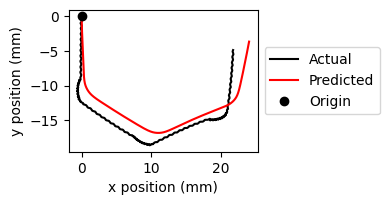

In [7]:
fig, ax = plt.subplots(figsize=(4, 4), tight_layout=True)
ax.plot(*path_integration_results["pos_actual"].T, c="k", label="Actual")
ax.plot(*path_integration_results["pos_pred"].T, c="r", label="Predicted")
ax.plot([0], [0], "ko", label="Origin")
ax.set_aspect("equal")
ax.set_xlabel("x position (mm)")
ax.set_ylabel("y position (mm)")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

From this very simple experiment, we can see that small errors in the heading estimation accumulate over time and lead to a large deviation from the intended path. In a naturalistic environment, the fly would have access to a few other sensory modalities. How those could be used to potentially improve the current framework will be explored in the rest of the exercise.

## Exercise 3: Optic flow based path integration

Last week, we explored how fruit flies can use vision to update heading through the optomotor reflex. In that context, the goal is to counteract unexpected whole-body perturbations during flight or walking.

In this exercise, we study a different role of vision: improving path integration. For simplicity, we will use [optic flow](https://en.wikipedia.org/wiki/Optical_flow), a signal known to be computed in flies, to estimate heading changes.

Experiments in **[Neural dynamics for landmark orientation and angular path integration](https://www.nature.com/articles/nature14446)** showed that flies can track visual cues. In virtual-reality experiments, a population of ellipsoid body neurons updates its activity so that the population code represents cue azimuth.

This is visible in panel h below, where the azimuth of the visual cue closely matches the location of the activity bump in the ellipsoid body.

<img src="assets/visual_orient_seelig2015.png" alt="https://www.nature.com/articles/nature14446/figures/1" width="700" data-background-color="white">

### What does the fly see?

To help with developing the model that predicts the fly's displacement based on optic flow, we will create a function that shows what the fly would see when facing a certain heading angle

In [8]:
import numpy as np


def get_vision_at_heading(heading_deg, render_camera=False):
    fly = create_fly(enable_vision=True)
    tracking_cam = fly.add_tracking_camera(**cam_params) if render_camera else None
    world = BaseBallArena()
    world.add_fly(
        fly, spawn_position=(0, 0, 0.2), spawn_rotation=heading_deg_to_quat(heading_deg)
    )
    world.add_light()
    sim = Simulation(world)
    if render_camera:
        sim.set_renderer(camera=tracking_cam, playback_speed=0.2, output_fps=25)
    sim.step()
    if render_camera:
        sim.render_as_needed()
        frame = sim.renderer.frames["nmf/trackcam"][0]
    else:
        frame = None
    ommatidia_readouts = sim.get_ommatidia_readouts(fly.name)
    return ommatidia_readouts.copy(), frame

Text(0.5, 1.0, 'Right eye')

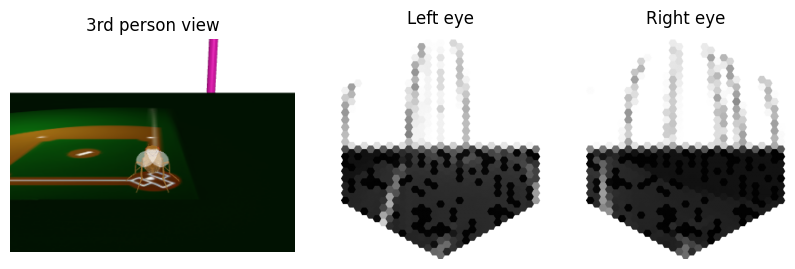

In [9]:
from flygym.vision.retina import Retina

retina = Retina()
ommatidia_id_map = retina.ommatidia_id_map


ommatidia_readouts, frame = get_vision_at_heading(-90, render_camera=True)
fig, axs = plt.subplots(
    1, 3, figsize=(10, 3), gridspec_kw={"width_ratios": [1, 0.7, 0.7]}
)
axs[0].imshow(frame)

for i in range(2):
    img = retina.hex_pxls_to_human_readable(
        ommatidia_readouts[i].max(-1), color_8bit=True
    )
    axs[i + 1].imshow(img, cmap="gray", vmin=0, vmax=255)

for ax in axs:
    ax.axis("off")

axs[0].set_title("3rd person view")
axs[1].set_title("Left eye")
axs[2].set_title("Right eye")

Doing image processing with hexagonal images is challenging, so we will resize the fly's vision to a rectangular image

In [10]:
def crop_hex_to_rect(visual_input):
    """Extract a rectangular crop from the hexagonal ommatidium layout."""
    rows = [np.unique(row) for row in ommatidia_id_map]
    max_width = max(len(row) for row in rows)
    rows = np.array([row for row in rows if len(row) == max_width])[:, 1:] - 1
    cols = [np.unique(col) for col in rows.T]
    min_height = min(len(col) for col in cols)
    cols = [col[:min_height] for col in cols]
    rows = np.array(cols).T
    return visual_input.max(-1)[..., rows]

We now simulate and visualise the fly's perspective from a number of different orientations

In [11]:
n_headings = 5
headings_deg = np.linspace(0, 22.5, n_headings)
ommatidia_readouts_list = [None] * n_headings
frame_list = [None] * n_headings
for j, heading_deg in enumerate(headings_deg):
    ommatidia_readouts_list[j], frame_list[j] = get_vision_at_heading(
        heading_deg, render_camera=True
    )

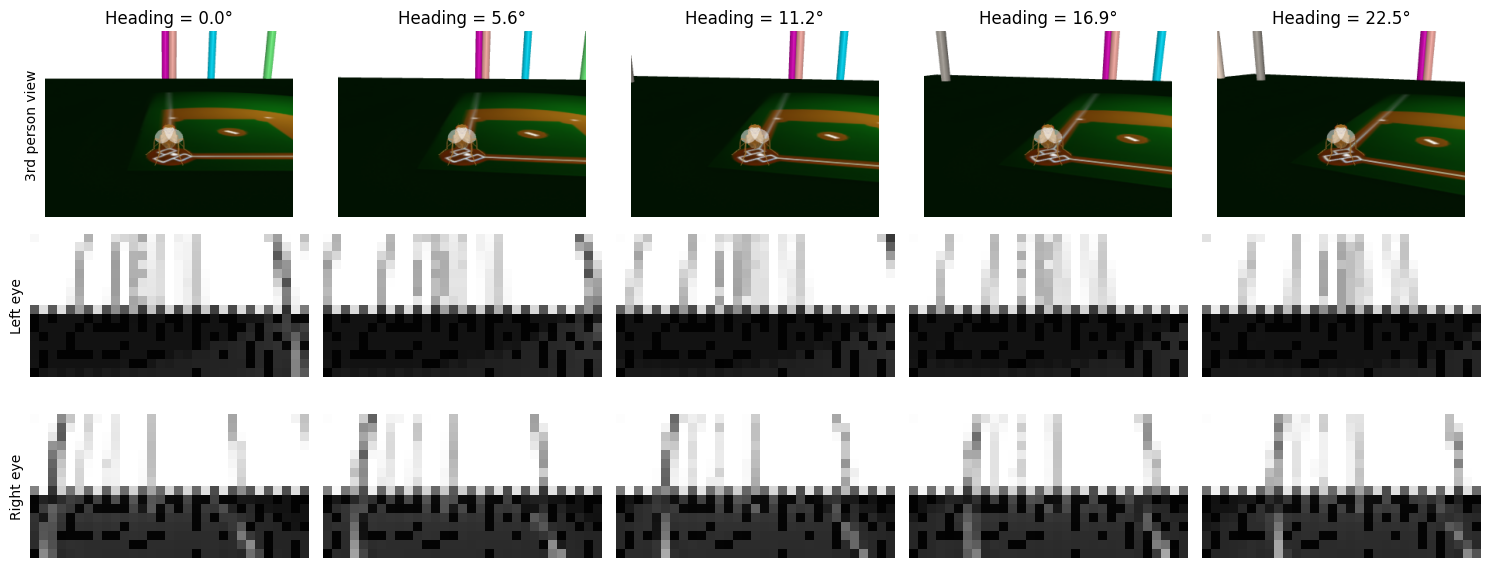

In [12]:
fig, axs = plt.subplots(3, n_headings, figsize=(n_headings * 3, 6), tight_layout=True)
for i in range(n_headings):
    imgs = crop_hex_to_rect(ommatidia_readouts_list[i])
    axs[0, i].imshow(frame_list[i])
    axs[1, i].imshow(imgs[0], cmap="gray", vmin=0, vmax=1)
    axs[2, i].imshow(imgs[1], cmap="gray", vmin=0, vmax=1)
    axs[0, i].set_title(f"Heading = {headings_deg[i]:.1f}°")

axs[0, 0].set_ylabel("3rd person view")
axs[1, 0].set_ylabel("Left eye")
axs[2, 0].set_ylabel("Right eye")

for ax in axs.ravel():
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

As the fly rotates, the objects in the image mainly move horizontally, with some distortion because of the "fish eye" like view that the fly has.

### Calculating optic flow between two images

If we look above, some parts of the image might be more useful for calculating optic flow than other parts.

We can preprocess these images to make the optic flow easier to detect.

In [13]:
################################################################
# TODO: Preprocess images from the fly's vision to make it easier to calculate optic flow


def preprocess_fly_vision(ommatidia_readouts):
    # return the result as np.uint8 image with values between 0 and 255
    images = crop_hex_to_rect(ommatidia_readouts)[:, :5]
    images = (images * 255).astype(np.uint8)
    return images

Now, we implement a function for computing the optic flow between two images - using the OpenCV `cv2.calcOpticalFlowFarneback` function.

We have already roughly tuned the parameters of this function for you, but feel free to play with them to get better results.

In [14]:
import cv2

optic_flow_kws = dict(
    flow=None,
    pyr_scale=0.5,
    levels=2,
    winsize=3,
    iterations=2,
    poly_n=5,
    poly_sigma=1.1,
    flags=0,
)


# perform optic flow
def compute_optic_flow_x(pre_imgs, post_imgs):
    return np.array(
        [
            cv2.calcOpticalFlowFarneback(pre_img, post_img, **optic_flow_kws)[..., 0]
            for pre_img, post_img in zip(pre_imgs, post_imgs)
        ]
    )


### Running optic flow calculations for simulated vision

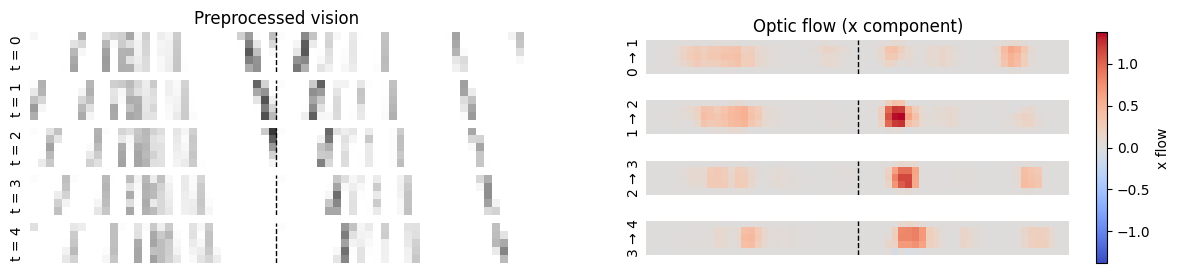

In [15]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from itertools import pairwise

fig = plt.figure(figsize=(15, 3))
outer = gridspec.GridSpec(1, 2, width_ratios=[1, 1])
gs_l = gridspec.GridSpecFromSubplotSpec(n_headings, 1, subplot_spec=outer[0])
axs_l = [fig.add_subplot(gs_l[i]) for i in range(n_headings)]
gs_r = gridspec.GridSpecFromSubplotSpec(n_headings - 1, 1, subplot_spec=outer[1])
axs_r = [fig.add_subplot(gs_r[i]) for i in range(n_headings - 1)]

preprocessed = [preprocess_fly_vision(i) for i in ommatidia_readouts_list]
flows = [compute_optic_flow_x(pre, post) for pre, post in pairwise(preprocessed)]

imshow_kws = {"cmap": "gray", "vmin": 0, "vmax": np.max(preprocessed)}
vmax = np.max(np.abs(flows))
flow_imshow_kws = {"cmap": "coolwarm", "vmin": -vmax, "vmax": vmax}

for i, (pre, post) in enumerate(pairwise(preprocessed)):
    if i == 0:
        axs_l[i].imshow(np.concatenate(pre, axis=1), **imshow_kws)
    axs_l[i + 1].imshow(np.concatenate(post, axis=1), **imshow_kws)
    axs_r[i].imshow(np.concatenate(flows[i], axis=1), **flow_imshow_kws)

for ax in axs_l + axs_r:
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    ax.axvline(preprocessed[0][0].shape[1] - 0.5, color="k", lw=1, ls="--")

for i, ax in enumerate(axs_l):
    ax.set_ylabel(f"t = {i}")

for i, ax in enumerate(axs_r):
    ax.set_ylabel(f"{i} → {i + 1}")

axs_r[0].set_title("Optic flow (x component)")
axs_l[0].set_title("Preprocessed vision")

fig.colorbar(
    ScalarMappable(norm=Normalize(vmin=-vmax, vmax=vmax), cmap="coolwarm"),
    ax=axs_r,
    location="right",
    label="x flow",
)

Next, let's examine the relationship between optic flow and changes in heading.

### Using optic flow to estimate heading change

Let's simulate the fly rotating and compare the fly's change in heading compared to the optic flow

In [16]:
from tqdm import tqdm

n_frames = 4
rot_speeds = np.array([0.05, 0.1, 0.5, 1, 2.5, 5, 7.5, 10, 15])
rot_speeds = np.concatenate([-rot_speeds[::-1], [0], rot_speeds])
n_speeds = len(rot_speeds)

In [17]:
mean_x_flows = np.empty((n_speeds, n_frames - 1))

for i, speed in enumerate(tqdm(rot_speeds)):
    headings_deg = np.arange(0, n_frames) * speed
    predicted_rolls = []
    prev_vis = None

    for j, heading_deg in enumerate(headings_deg):
        ommatidia_readouts = get_vision_at_heading(heading_deg)[0]
        curr_vis = preprocess_fly_vision(ommatidia_readouts)

        if j > 0:
            mean_x_flows[i, j - 1] = compute_optic_flow_x(prev_vis, curr_vis).mean()

        prev_vis = curr_vis

100%|██████████| 19/19 [01:45<00:00,  5.54s/it]


Text(0, 0.5, 'Mean optic flow in x direction')

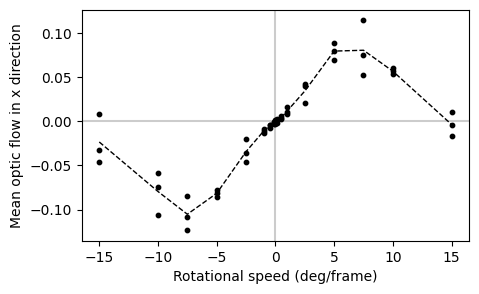

In [18]:
fig, ax = plt.subplots(figsize=(5, 3))

ax.scatter(
    rot_speeds.repeat(n_frames - 1),
    mean_x_flows.ravel(),
    c="k",
    s=10,
)
ax.plot(rot_speeds, mean_x_flows.mean(axis=-1), c="k", lw=1, ls="--")
ax.axhline(0, c="k", linestyle="-", alpha=0.2)
ax.axvline(0, c="k", linestyle="-", alpha=0.2)
ax.set_xlabel("Rotational speed (deg/frame)")
ax.set_ylabel("Mean optic flow in x direction")

**Questions:**

* Why does this curve have this shape?
* Why does the predicted change in heading decrease again after a certain rotation speed?

**Answer:**

Beyond a certain angular change between two frames, matching visual features becomes difficult. When correspondence fails, optic flow estimates become noisy and the mean x-flow is no longer a reliable proxy for heading change. This is why the curve can flatten or even turn down at large rotations.

At the other end of the range, very small heading changes can also be hard to detect because the fly-eye image changes only slightly. In our simulation, this effect is amplified by limited spatial resolution.

*Note:* A real fly may achieve higher effective resolution than this simplified sensor model. Although our model has a realistic number of ommatidia, real flies can actively shift optical axes, which may improve resolution through temporal comparisons. See [this paper](https://www.nature.com/articles/s41586-022-05317-5).

### Predicting heading during locomotion

To calculate optic flow after the simulation, we need a new simulation function that stores the images during the simulation so we can analyse them later

In [19]:
dn_drives = np.repeat([[1.0, 1.0], [-0.2, 1.0]], [5000, 8000], axis=0)

vision_update_interval = 0.016
vision_update_steps = int(vision_update_interval / time_step)


def run_simulation_with_vision(dn_drives: np.ndarray):
    """Run one trial and periodically record mean x optic flow."""
    fly = create_fly(enable_vision=True)
    tracking_cam = fly.add_tracking_camera(**cam_params)
    world = BaseBallArena()
    world.add_fly(
        fly,
        spawn_position=(0, 0, 0.2),
        spawn_rotation=heading_deg_to_quat(-90),
    )
    world.add_light()
    sim = Simulation(world)
    sim.set_renderer(camera=tracking_cam, playback_speed=0.2, output_fps=25)
    controller = TurningController(sim.timestep)

    prev_imgs = None
    mean_x_flows = []

    n_steps = len(dn_drives)
    hist = History(n_steps, sim, fly.name)

    for i in trange(n_steps):
        joint_angles, adhesion = controller.step(dn_drives[i])
        sim.set_actuator_inputs(fly.name, ActuatorType.POSITION, joint_angles)
        sim.set_actuator_inputs(fly.name, ActuatorType.ADHESION, adhesion)
        sim.step()
        sim.render_as_needed()
        hist.step(i)

        if i % vision_update_steps == 0:
            curr_imgs = preprocess_fly_vision(sim.get_ommatidia_readouts(fly.name))
            if prev_imgs is not None:
                mean_x_flows.append(compute_optic_flow_x(prev_imgs, curr_imgs).mean())
            prev_imgs = curr_imgs

    data = hist.to_dict()
    data["mean_x_flows"] = np.array(mean_x_flows)
    return sim, data


sim, data = run_simulation_with_vision(dn_drives)
show_video(sim)

100%|██████████| 13000/13000 [00:05<00:00, 2253.92it/s]


nmf/trackcam This browser does not support the video tag.


We can then compare the ground truth heading change to the optic flow predicted heading change, fitting a linear model between the two

R² of linear regression: 0.854


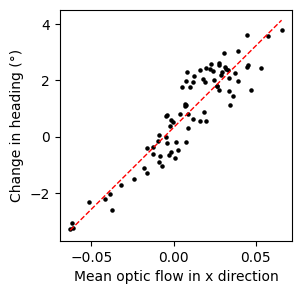

In [20]:
from sklearn.linear_model import LinearRegression

mean_x_flows = data["mean_x_flows"]
heading_change = np.diff(data["heading"][::vision_update_steps])

fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(mean_x_flows, np.rad2deg(heading_change), lw=1, c="k", s=5)
ax.set_xlabel("Mean optic flow in x direction")
ax.set_ylabel(r"Change in heading (°)")

model = LinearRegression().fit(mean_x_flows[:, None], heading_change)
r2 = model.score(mean_x_flows[:, None], heading_change)
x = np.array([mean_x_flows.min(), mean_x_flows.max()])
ax.plot(
    x, np.rad2deg(model.predict(x[:, None])), c="r", lw=1, ls="--", label="Linear fit"
)
print(f"R² of linear regression: {r2:.3f}")

In [21]:
dn_drives = build_square_open_loop_drives(forward_steps, turn_steps)
sim, data = run_simulation_with_vision(dn_drives)

100%|██████████| 64200/64200 [00:19<00:00, 3242.05it/s]


Now we can predict the estimated position of the fly based on proprioception and optic flow

In [22]:
heading_pred = np.cumsum(
    np.concatenate([[0], model.predict(data["mean_x_flows"][:, None])])
)
heading_pred_interp = np.interp(
    np.arange(len(data["heading"])) * time_step,
    np.arange(len(heading_pred)) * vision_update_interval,
    heading_pred,
)
heading_win_diff_pred = heading_pred_interp[win_len:] - heading_pred_interp[:-win_len]

In [23]:
path_integration_results = path_integrate(
    data,
    lambda x: heading_win_diff_pred,
    fwd_disp_model,
    win_len,
    adhesion_force_thr,
)

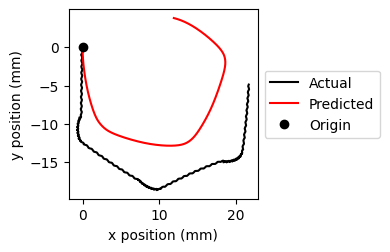

In [24]:
fig, ax = plt.subplots(figsize=(4, 4), tight_layout=True)
ax.plot(*path_integration_results["pos_actual"].T, c="k", label="Actual")
ax.plot(*path_integration_results["pos_pred"].T, c="r", label="Predicted")
ax.plot([0], [0], "ko", label="Origin")
ax.set_aspect("equal")
ax.set_xlabel("x position (mm)")
ax.set_ylabel("y position (mm)")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

## Exercise 4: Polarized Light Based Path Integration

Insects such as bees and ants are known to use [polarized light](https://en.wikipedia.org/wiki/Polarization_(waves)) to estimate heading. Although sunlight is unpolarized, scattering in the atmosphere polarizes skylight. Specialized photoreceptors in the dorsal rim area can detect this polarization direction, which is relatively stable on behavioral timescales. This provides a compass-like reference for heading estimation.

*Bees even use polarized light to communicate food-source location; see [this article](https://www.science.org/doi/10.1126/science.ade1702).*

NeuroMechFly does not currently model polarized-light sensing in detail. Since our goal here is path-integration behavior rather than full sensory physiology, we approximate this modality by directly supplying absolute ("ground truth") heading information from the simulation.

In [25]:
path_integration_results = path_integrate(
    data,
    heading_model=lambda x: wrap_to_pi(
        data["heading"][win_len:] - data["heading"][:-win_len]
    ),
    fwd_disp_model=fwd_disp_model,
    win_len=win_len,
    adhesion_force_thr=adhesion_force_thr,
)

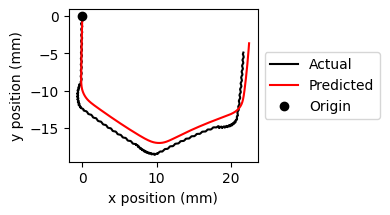

In [26]:
fig, ax = plt.subplots(figsize=(4, 4), tight_layout=True)
ax.plot(*path_integration_results["pos_actual"].T, c="k", label="Actual")
ax.plot(*path_integration_results["pos_pred"].T, c="r", label="Predicted")
ax.plot([0], [0], "ko", label="Origin")
ax.set_aspect("equal")
ax.set_xlabel("x position (mm)")
ax.set_ylabel("y position (mm)")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

**Question:**

Why does having an absolute sense of direction allow the fly to do path integration more accurately?

**Answer:**

Because the fly updates its position estimate based on its current heading estimate, errors in heading are magnified by this integration process. Having access to the true heading angle therefore significantly increases the accuracy of the fly's path integration.

## Exercise 5: Closed loop path integration with polarized light

Now that the fly is able to accurately track its position and heading over time, it can use this estimate of its position to correct errors in its movements and better follow the square trajectory.

This is call "closed loop" control - where the fly's actions affect its sensory experience and it can use this sensory information to better choose future actions.

### Step 1: Implement a simulation loop with "real time" path integration

To be able to control the fly's actions based on its position estimate, the fly needs to estimate its position *during* the simulation.

First, reimplement one of the simulation loops above, but instead of recording all the data from the simulation and performing path integration at the end, do path integration during the simulation.

Choose your favourite path integration model from one of the previous exercises in this notebook for this.

### Step 2: Use the fly's estimate of its position for controlling its actions

Instead of implementing a biologically inspired controller based on the fly, we can instead simplify things by using a control approach from robotics such as from section 4.2.1 in [Corke et al., 2011](https://doi.org/10.1007/978-3-642-20144-8).

Given a current position and heading $(x,y,\theta)$ and a desired goal position $(x^*,y^*)$, the controller outputs a distance error $\delta_v$ and angle to the goal $\theta^*$

$$\begin{aligned}
    \delta_v &= \sqrt{(x^* - x)^2 + (y^* - y)^2} \\
    \theta^* &= \tan^{-1} \left(\frac{y^* - y}{x^* - x}\right)
\end{aligned}$$

These quantities are then used in a proportional controller to output the desired linear and rotational velocity of the fly

$$\begin{aligned}
    v^* &= K_v \delta_v \\
    \omega^* &= K_h (\theta^* \ominus \theta)
\end{aligned}$$

where $\ominus$ is the wrapped angular difference function, which returns a result in the range $[-\pi,\pi)$.

 19%|█▉        | 19238/100000 [00:04<00:19, 4135.23it/s]

Reached goal!


 38%|███▊      | 38293/100000 [00:09<00:14, 4181.08it/s]

Reached goal!


 57%|█████▋    | 57249/100000 [00:13<00:10, 4232.47it/s]

Reached goal!


 75%|███████▌  | 75483/100000 [00:18<00:05, 4176.81it/s]


Finished


nmf/trackcam This browser does not support the video tag.


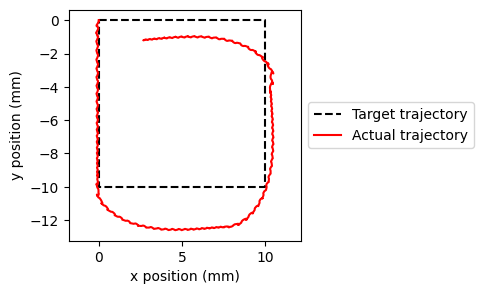

In [27]:
fly = create_fly()
tracking_cam = fly.add_tracking_camera(**cam_params)
world = BaseBallArena()
world.add_fly(
    fly,
    spawn_position=(0, 0, 0.2),
    spawn_rotation=heading_deg_to_quat(-90),
)
world.add_light()

sim = Simulation(world)
sim.set_renderer(
    camera=tracking_cam,
    playback_speed=0.2,
    output_fps=25,
)

controller = TurningController(sim.timestep)
n_steps = 100000
goal_radius = 2.0
speed_gain = 1 / 20
heading_gain = 2.0

goals = np.array([[0, -1], [1, -1], [1, 0], [0, 0]]) * square_size
current_goal_index = 0

body = sim.mj_data.body(f"{fly.name}/")
legs = ["lf", "lm", "lh", "rf", "rm", "rh"]
tarsus_ids = np.array(
    [sim.mj_data.body(f"{fly.name}/{leg}_tarsus5").id for leg in legs]
)


def get_heading_vec():
    w, x, y, z = body.xquat
    return np.array([1.0 - 2.0 * (y * y + z * z), 2.0 * (w * z + x * y)])


def get_pos():
    return body.xpos[:2].copy()


def get_rel_leg_tip_pos(pos, heading_vec):
    return (sim.mj_data.xpos[tarsus_ids, :2] - pos) @ heading_vec


last_rel_leg_tip_pos = None
stride_cum = []
pred_pos_hist = [np.zeros(2)]
pos_hist = []
heading_hist = []

for _ in trange(n_steps):
    true_heading_vec = get_heading_vec()
    true_heading = np.arctan2(true_heading_vec[1], true_heading_vec[0])
    true_pos = get_pos()
    pred_pos = pred_pos_hist[-1]

    error = goals[current_goal_index] - pred_pos
    error_dist = np.linalg.norm(error)
    goal_heading = np.arctan2(error[1], error[0])
    error_heading = wrap_to_pi(goal_heading - true_heading)

    speed_control = np.sqrt(speed_gain * error_dist)
    speed_heading = heading_gain * error_heading
    speed_left = speed_control * (1 - speed_heading / 2)
    speed_right = speed_control * (1 + speed_heading / 2)

    if error_dist < goal_radius:
        if current_goal_index < len(goals) - 1:
            print("Reached goal!")
            current_goal_index += 1
        else:
            print("Finished")
            break

    dn_drive = np.array([speed_left, speed_right])
    joint_angles, adhesion = controller.step(dn_drive)
    sim.set_actuator_inputs(fly.name, ActuatorType.POSITION, joint_angles)
    sim.set_actuator_inputs(fly.name, ActuatorType.ADHESION, adhesion)
    sim.step()
    sim.render_as_needed()

    pos_hist.append(true_pos)
    heading_hist.append(true_heading_vec)

    adhesion_force = sim.get_adhesion_force_magnitudes(fly.name)
    contact_mask = adhesion_force >= adhesion_force_thr
    rel_leg_tip_pos = get_rel_leg_tip_pos(true_pos, true_heading_vec)

    if last_rel_leg_tip_pos is None:
        stride_diff = np.zeros_like(rel_leg_tip_pos)
    else:
        stride_diff = (rel_leg_tip_pos - last_rel_leg_tip_pos) * contact_mask
    last_rel_leg_tip_pos = rel_leg_tip_pos

    stride_cum.append(stride_cum[-1] + stride_diff if stride_cum else stride_diff)
    if len(stride_cum) <= win_len:
        continue

    stride_win_diff = stride_cum[-1] - stride_cum[-1 - win_len]
    stride_win_diff_l = stride_win_diff[:3]
    stride_win_diff_r = stride_win_diff[3:6]
    stride_win_diff_lr_sum = stride_win_diff_l + stride_win_diff_r

    fwd_disp_win_diff_pred = fwd_disp_model(stride_win_diff_lr_sum[None])[0]
    pred_pos_hist.append(
        pred_pos_hist[-1] + fwd_disp_win_diff_pred * true_heading_vec / win_len
    )
    stride_cum.pop(0)

plot_square_trajectory(np.array(pos_hist))
show_video(sim)